# Импорт библиотек


In [1]:

# Импорт библиотек
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime
import warnings
warnings.filterwarnings('ignore')

# Настройка стилей для визуализации
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

# Загрузка и подготвка данных

In [2]:


# Загрузка данных
df = pd.read_csv('PP12_ISP22_analytics.csv', parse_dates=['date'])

# Предварительный просмотр
print(f" Размер датасета: {df.shape[0]} строк × {df.shape[1]} столбцов")
print(f" Период данных: {df['date'].min().date()} — {df['date'].max().date()}")
print(f"\n Структура данных:\n{df.dtypes}")

 Размер датасета: 400 строк × 6 столбцов
 Период данных: 2023-01-01 — 2024-02-04

 Структура данных:
date         datetime64[ns]
revenue               int64
expenses              int64
customers             int64
orders                int64
profit                int64
dtype: object


In [3]:
# =============================================================================
# 1.1 ОЧИСТКА ДАННЫХ
# =============================================================================

# Проверка на пропуски
missing_values = df.isnull().sum()
print(f"Пропущенные значения:\n{missing_values[missing_values > 0] if missing_values.any() else 'Отсутствуют'}")

# Проверка на дубликаты
duplicates = df.duplicated().sum()
print(f"Дубликаты записей: {duplicates}")

# Статистика по числовым переменным
print(f"\nОписательная статистика:\n{df[['revenue', 'expenses', 'profit', 'customers', 'orders']].describe().round(2)}")

Пропущенные значения:
Отсутствуют
Дубликаты записей: 0

Описательная статистика:
         revenue   expenses     profit  customers  orders
count     400.00     400.00     400.00     400.00  400.00
mean   124795.49   84243.50   40552.00     272.31  162.81
std     43373.32   36595.76   54752.77     132.14   79.06
min     50207.00   20163.00  -89039.00      51.00   20.00
25%     85504.25   50785.75    6535.50     155.75   94.00
50%    126206.50   81445.00   41091.00     263.00  166.00
75%    164021.50  116487.00   80278.50     398.25  229.00
max    199381.00  149226.00  169601.00     497.00  299.00


In [4]:
# =============================================================================
# 1.2 ПРЕОБРАЗОВАНИЕ ДАННЫХ
# =============================================================================

# Добавление вспомогательных колонок
df['month'] = df['date'].dt.to_period('M')
df['weekday'] = df['date'].dt.day_name()
df['profit_margin'] = (df['profit'] / df['revenue'] * 100).round(2)  # Рентабельность, %
df['avg_order_value'] = (df['revenue'] / df['orders']).round(2)  # Средний чек
df['revenue_per_customer'] = (df['revenue'] / df['customers']).round(2)  # Выручка на клиента
df['quarter'] = df['date'].dt.quarter
# Группировка по месяцам для анализа динамики
monthly_df = df.groupby('month').agg({
    'revenue': 'sum',
    'expenses': 'sum',
    'profit': 'sum',
    'customers': 'sum',
    'orders': 'sum'
}).reset_index()
monthly_df['profit_margin'] = (monthly_df['profit'] / monthly_df['revenue'] * 100).round(2)

print("✅ Данные подготовлены и преобразованы")
print(f"📈 Добавлены метрики: profit_margin, avg_order_value, revenue_per_customer")

✅ Данные подготовлены и преобразованы
📈 Добавлены метрики: profit_margin, avg_order_value, revenue_per_customer


In [5]:
# =============================================================================
# 2. ОБЩИЕ ПОКАЗАТЕЛИ И РАСЧЁТ МЕТРИК
# =============================================================================

print("="*70)
print("📊 СВОДНЫЕ ПОКАЗАТЕЛИ ДЕЯТЕЛЬНОСТИ")
print("="*70)

# --- Расчет базовых показателей ---
total_revenue = df['revenue'].sum()
total_expenses = df['expenses'].sum()
total_profit = df['profit'].sum()
total_customers = df['customers'].sum()
total_orders = df['orders'].sum()
avg_margin = df['profit_margin'].mean()
profitable_days = (df['profit'] > 0).sum()
loss_days = (df['profit'] < 0).sum()

# --- Динамика изменений (месяц к месяцу) ---
monthly_df['revenue_growth'] = monthly_df['revenue'].pct_change() * 100
monthly_df['profit_growth'] = monthly_df['profit'].pct_change() * 100

# --- Вывод финансовых результатов ---
print(f"""
💰 ФИНАНСОВЫЕ РЕЗУЛЬТАТЫ (за весь период):
   • Общая выручка:           {total_revenue:,.0f} руб.
   • Общие расходы:           {total_expenses:,.0f} руб.
   • Чистая прибыль:          {total_profit:,.0f} руб.
   • Средняя маржинальность:  {avg_margin:.2f}%

📈 ОПЕРАЦИОННЫЕ ПОКАЗАТЕЛИ:
   • Всего клиентов:          {total_customers:,} чел.
   • Всего заказов:           {total_orders:,} ед.
   • Средний чек:             {df['avg_order_value'].mean():,.2f} руб.
   • Выручка на клиента:      {df['revenue_per_customer'].mean():,.2f} руб.

📊 СРЕДНИЕ ЗНАЧЕНИЯ (в день):
   • Средняя выручка:         {df['revenue'].mean():,.0f} руб.
   • Средние расходы:         {df['expenses'].mean():,.0f} руб.
   • Средняя прибыль:         {df['profit'].mean():,.0f} руб.
   • Среднее кол-во клиентов: {df['customers'].mean():.0f} чел.
   • Среднее кол-во заказов:  {df['orders'].mean():.0f} ед.
   • Средняя рентабельность:  {df['profit_margin'].mean():.2f}%

📊 ЭФФЕКТИВНОСТЬ:
   • Прибыльных дней:         {profitable_days} ({profitable_days/len(df)*100:.1f}%)
   • Убыточных дней:          {loss_days} ({loss_days/len(df)*100:.1f}%)
   • Коэффициент прибыльности:{profitable_days/loss_days:.2f}

🥧 ДОЛЕВЫЕ ПОКАЗАТЕЛИ:
   • Доля расходов в выручке: {(total_expenses/total_revenue*100):.1f}%
   • Доля прибыли в выручке:  {(total_profit/total_revenue*100):.1f}%
""")

# --- Динамика изменений (последние 6 месяцев) ---
print("📈 ДИНАМИКА ИЗМЕНЕНИЙ (месяц к месяцу, последние 6 периодов):")
print(monthly_df[['month', 'revenue', 'profit', 'revenue_growth', 'profit_growth']].tail(6).round(2).to_string(index=False))

📊 СВОДНЫЕ ПОКАЗАТЕЛИ ДЕЯТЕЛЬНОСТИ

💰 ФИНАНСОВЫЕ РЕЗУЛЬТАТЫ (за весь период):
   • Общая выручка:           49,918,197 руб.
   • Общие расходы:           33,697,398 руб.
   • Чистая прибыль:          16,220,799 руб.
   • Средняя маржинальность:  22.87%

📈 ОПЕРАЦИОННЫЕ ПОКАЗАТЕЛИ:
   • Всего клиентов:          108,925 чел.
   • Всего заказов:           65,123 ед.
   • Средний чек:             1,156.84 руб.
   • Выручка на клиента:      632.71 руб.

📊 СРЕДНИЕ ЗНАЧЕНИЯ (в день):
   • Средняя выручка:         124,795 руб.
   • Средние расходы:         84,243 руб.
   • Средняя прибыль:         40,552 руб.
   • Среднее кол-во клиентов: 272 чел.
   • Среднее кол-во заказов:  163 ед.
   • Средняя рентабельность:  22.87%

📊 ЭФФЕКТИВНОСТЬ:
   • Прибыльных дней:         307 (76.8%)
   • Убыточных дней:          93 (23.2%)
   • Коэффициент прибыльности:3.30

🥧 ДОЛЕВЫЕ ПОКАЗАТЕЛИ:
   • Доля расходов в выручке: 67.5%
   • Доля прибыли в выручке:  32.5%

📈 ДИНАМИКА ИЗМЕНЕНИЙ (месяц к месяцу, последние

In [6]:
# =============================================================================
# 3. АНАЛИЗ ДАННЫХ
# =============================================================================

# 3.1 Выявление трендов
print("🔍 АНАЛИЗ ТРЕНДОВ:")

# Тренд прибыли
profit_trend = np.polyfit(range(len(monthly_df)), monthly_df['profit'], 1)
trend_direction = "📈 Рост" if profit_trend[0] > 0 else "📉 Снижение"
print(f"• Тренд прибыли: {trend_direction} (коэф. наклона: {profit_trend[0]:.0f})")

# Сезонность по месяцам
monthly_pattern = df.groupby(df['date'].dt.month)['revenue'].mean()
best_month = monthly_pattern.idxmax()
worst_month = monthly_pattern.idxmin()
print(f"• Наиболее успешный месяц: {best_month} (сред. выручка: {monthly_pattern[best_month]:,.0f} руб.)")
print(f"• Наименее успешный месяц: {worst_month} (сред. выручка: {monthly_pattern[worst_month]:,.0f} руб.)")

# 3.2 Сравнение периодов
print(f"\n🔄 СРАВНЕНИЕ ПЕРИОДОВ (2023 vs 2024):")
df['year'] = df['date'].dt.year
comparison = df.groupby('year')[['revenue', 'expenses', 'profit', 'customers', 'orders']].sum()
print(comparison)

# 3.3 Поиск зависимостей (корреляционный анализ)
print(f"\n🔗 КОРРЕЛЯЦИИ МЕЖДУ ПОКАЗАТЕЛЯМИ:")
corr_matrix = df[['revenue', 'expenses', 'profit', 'customers', 'orders']].corr()
print(corr_matrix.round(3))

# Выявление сильных зависимостей
strong_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            strong_corr.append(f"• {corr_matrix.index[i]} ↔ {corr_matrix.columns[j]}: {corr_matrix.iloc[i, j]:.3f}")
print(f"\nСильные корреляции (|r| > 0.7):\n" + "\n".join(strong_corr))

🔍 АНАЛИЗ ТРЕНДОВ:
• Тренд прибыли: 📉 Снижение (коэф. наклона: -46326)
• Наиболее успешный месяц: 2 (сред. выручка: 139,536 руб.)
• Наименее успешный месяц: 9 (сред. выручка: 116,499 руб.)

🔄 СРАВНЕНИЕ ПЕРИОДОВ (2023 vs 2024):
       revenue  expenses    profit  customers  orders
year                                                 
2023  45624348  30819214  14805134      98903   59172
2024   4293849   2878184   1415665      10022    5951

🔗 КОРРЕЛЯЦИИ МЕЖДУ ПОКАЗАТЕЛЯМИ:
           revenue  expenses  profit  customers  orders
revenue      1.000     0.070   0.745      0.045  -0.031
expenses     0.070     1.000  -0.613     -0.005  -0.017
profit       0.745    -0.613   1.000      0.039  -0.013
customers    0.045    -0.005   0.039      1.000  -0.026
orders      -0.031    -0.017  -0.013     -0.026   1.000

Сильные корреляции (|r| > 0.7):
• revenue ↔ profit: 0.745


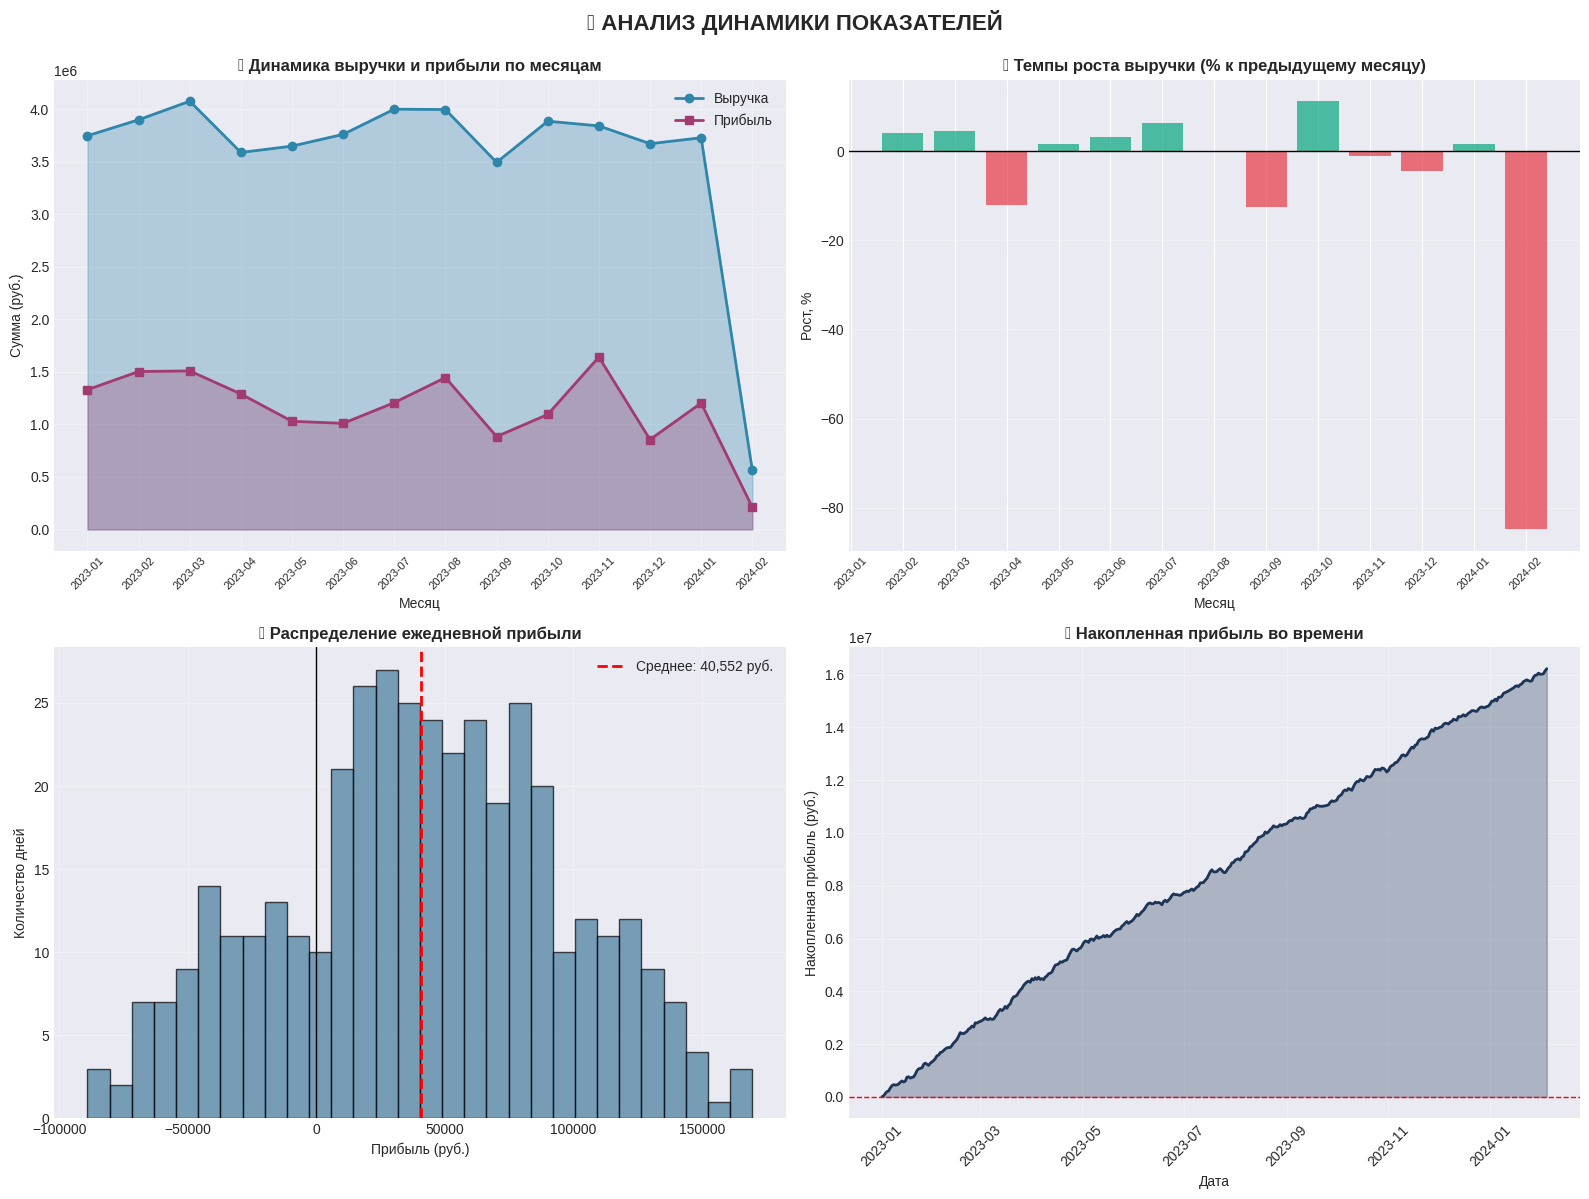

In [7]:
# =============================================================================
# 3. ВИЗУАЛИЗАЦИЯ 1: ДИНАМИКА ВЫРУЧКИ И ПРИБЫЛИ
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📈 АНАЛИЗ ДИНАМИКИ ПОКАЗАТЕЛЕЙ', fontsize=16, fontweight='bold', y=0.995)

# График 1: Динамика выручки и прибыли по месяцам
axes[0, 0].plot(range(len(monthly_df)), monthly_df['revenue'],
                marker='o', linewidth=2, label='Выручка', color='#2E86AB')
axes[0, 0].plot(range(len(monthly_df)), monthly_df['profit'],
                marker='s', linewidth=2, label='Прибыль', color='#A23B72')
axes[0, 0].fill_between(range(len(monthly_df)), monthly_df['revenue'], alpha=0.3, color='#2E86AB')
axes[0, 0].fill_between(range(len(monthly_df)), monthly_df['profit'], alpha=0.3, color='#A23B72')

axes[0, 0].set_title('📊 Динамика выручки и прибыли по месяцам', fontweight='bold')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Сумма (руб.)')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(range(len(monthly_df)))
axes[0, 0].set_xticklabels(monthly_df['month'].astype(str), rotation=45, fontsize=8)

# График 2: Темпы роста (month-over-month)
axes[0, 1].bar(range(len(monthly_df)), monthly_df['revenue_growth'],
               color=['#06A77D' if x > 0 else '#E63946' for x in monthly_df['revenue_growth']],
               alpha=0.7, label='Рост выручки')
axes[0, 1].axhline(y=0, color='black', linewidth=1)
axes[0, 1].set_title('📈 Темпы роста выручки (% к предыдущему месяцу)', fontweight='bold')
axes[0, 1].set_xlabel('Месяц')
axes[0, 1].set_ylabel('Рост, %')
axes[0, 1].set_xticks(range(len(monthly_df)))
axes[0, 1].set_xticklabels(monthly_df['month'].astype(str), rotation=45, fontsize=8)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# График 3: Распределение ежедневной прибыли
colors_dist = ['#06A77D' if x > 0 else '#E63946' for x in df['profit']]
axes[1, 0].hist(df['profit'], bins=30, color='#457B9D', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['profit'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Среднее: {df["profit"].mean():,.0f} руб.')
axes[1, 0].axvline(0, color='black', linestyle='-', linewidth=1)
axes[1, 0].set_title('📊 Распределение ежедневной прибыли', fontweight='bold')
axes[1, 0].set_xlabel('Прибыль (руб.)')
axes[1, 0].set_ylabel('Количество дней')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Кумулятивная прибыль
df_sorted = df.sort_values('date').copy()
df_sorted['cumulative_profit'] = df_sorted['profit'].cumsum()
axes[1, 1].plot(df_sorted['date'], df_sorted['cumulative_profit'],
                linewidth=2, color='#1D3557')
axes[1, 1].fill_between(df_sorted['date'], df_sorted['cumulative_profit'],
                        alpha=0.3, color='#1D3557')
axes[1, 1].axhline(y=0, color='red', linestyle='--', linewidth=1)
axes[1, 1].set_title('📈 Накопленная прибыль во времени', fontweight='bold')
axes[1, 1].set_xlabel('Дата')
axes[1, 1].set_ylabel('Накопленная прибыль (руб.)')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('analytics_dynamics.png', dpi=300, bbox_inches='tight')
plt.show()

# Анализ динамики показателей

**График первый — Динамика выручки и прибыли по месяцам**
- Период: январь 2023 — февраль 2024
- Выручка: колеблется в диапазоне 3.5–4.1 млн рублей, резкое падение в феврале 2024
- Прибыль: варьируется от 0.9 до 1.6 млн рублей
- Пик прибыли: ноябрь 2023 года
- Обе метрики показывают синхронную динамику

**График второй — Темпы роста выручки (% к предыдущему месяцу)**
- Положительный рост: январь-март 2023, май-июль 2023, октябрь 2023
- Отрицательная динамика: апрель 2023, август-сентябрь 2023, декабрь 2023
- Критическое падение: февраль 2024 (около −80%)
- Наиболее сильный рост: октябрь 2023 (около +15%)

**График третий — Распределение ежедневной прибыли**
- Средняя ежедневная прибыль: 40 552 рубля
- Диапазон: от −100 000 до +150 000 рублей
- Большинство дней: прибыль в диапазоне 20 000–80 000 рублей
- Убыточные дни присутствуют, но в меньшинстве

**График четвёртый — Накопленная прибыль во времени**
- Период: январь 2023 — февраль 2024
- Общая накопленная прибыль: около 1.6 × 10⁷ рублей (16 млн)
- Стабильный восходящий тренд без серьёзных откатов
- Критическая точка: февраль 2024 (резкое замедление роста)

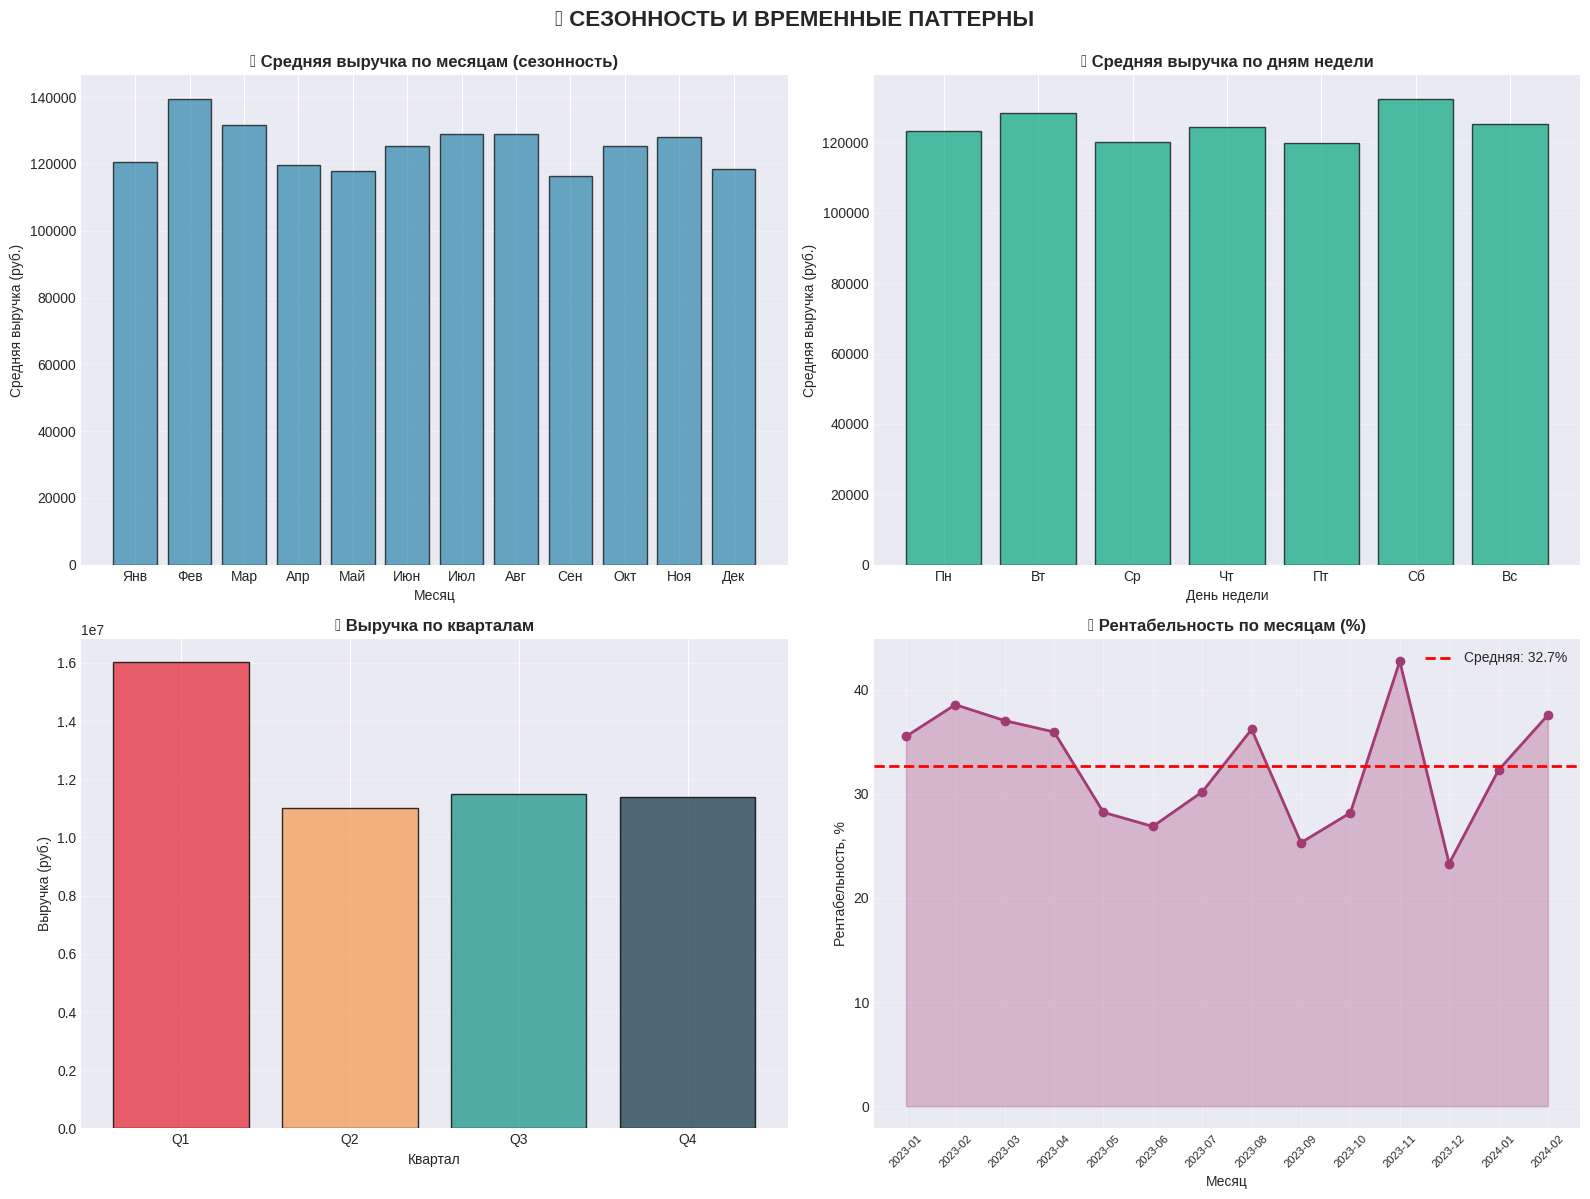

In [8]:
# =============================================================================
# 4. ВИЗУАЛИЗАЦИЯ 2: СЕЗОННОСТЬ И ПАТТЕРНЫ
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('📅 СЕЗОННОСТЬ И ВРЕМЕННЫЕ ПАТТЕРНЫ', fontsize=16, fontweight='bold', y=0.995)

# График 1: Средние показатели по месяцам (сезонность)
monthly_pattern = df.groupby(df['date'].dt.month).agg({
    'revenue': 'mean',
    'profit': 'mean',
    'profit_margin': 'mean'
}).reset_index()

months_names = ['Янв', 'Фев', 'Мар', 'Апр', 'Май', 'Июн',
                'Июл', 'Авг', 'Сен', 'Окт', 'Ноя', 'Дек']

axes[0, 0].bar(range(1, 13), monthly_pattern['revenue'],
               color='#2E86AB', alpha=0.7, edgecolor='black')
axes[0, 0].set_title('📊 Средняя выручка по месяцам (сезонность)', fontweight='bold')
axes[0, 0].set_xlabel('Месяц')
axes[0, 0].set_ylabel('Средняя выручка (руб.)')
axes[0, 0].set_xticks(range(1, 13))
axes[0, 0].set_xticklabels(months_names)
axes[0, 0].grid(True, alpha=0.3, axis='y')

# График 2: Средние показатели по дням недели
weekday_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
weekday_names = ['Пн', 'Вт', 'Ср', 'Чт', 'Пт', 'Сб', 'Вс']


weekday_pattern = df.groupby('weekday')[['revenue', 'profit']].mean().reindex(weekday_order)

axes[0, 1].bar(range(7), weekday_pattern['revenue'],
               color='#06A77D', alpha=0.7, edgecolor='black')
axes[0, 1].set_title('📊 Средняя выручка по дням недели', fontweight='bold')
axes[0, 1].set_xlabel('День недели')
axes[0, 1].set_ylabel('Средняя выручка (руб.)')
axes[0, 1].set_xticks(range(7))
axes[0, 1].set_xticklabels(weekday_names)
axes[0, 1].grid(True, alpha=0.3, axis='y')

# График 3: Распределение по кварталам


quarterly_df = df.groupby('quarter').agg({
    'revenue': 'sum',
    'profit': 'sum',
    'customers': 'sum'
}).reset_index()

axes[1, 0].bar(['Q1', 'Q2', 'Q3', 'Q4'], quarterly_df['revenue'],
               color=['#E63946', '#F4A261', '#2A9D8F', '#264653'],
               edgecolor='black', alpha=0.8)
axes[1, 0].set_title('💰 Выручка по кварталам', fontweight='bold')
axes[1, 0].set_xlabel('Квартал')
axes[1, 0].set_ylabel('Выручка (руб.)')
axes[1, 0].grid(True, alpha=0.3, axis='y')

# График 4: Рентабельность по месяцам
axes[1, 1].plot(range(len(monthly_df)), monthly_df['profit_margin'],
                marker='o', linewidth=2, color='#A23B72')
axes[1, 1].fill_between(range(len(monthly_df)), monthly_df['profit_margin'],
                        alpha=0.3, color='#A23B72')
axes[1, 1].axhline(monthly_df['profit_margin'].mean(), color='red', linestyle='--',
                   linewidth=2, label=f'Средняя: {monthly_df["profit_margin"].mean():.1f}%')
axes[1, 1].set_title('📈 Рентабельность по месяцам (%)', fontweight='bold')
axes[1, 1].set_xlabel('Месяц')
axes[1, 1].set_ylabel('Рентабельность, %')
axes[1, 1].set_xticks(range(len(monthly_df)))
axes[1, 1].set_xticklabels(monthly_df['month'].astype(str), rotation=45, fontsize=8)
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analytics_seasonality.png', dpi=300, bbox_inches='tight')
plt.show()

# Сезонность и временные паттерны

**График первый — Средняя выручка по месяцам (сезонность)**
- Пик выручки: февраль (около 140 000 рублей)
- Высокие показатели: март, июль, август, ноябрь (125 000–130 000 рублей)
- Спады: май, сентябрь, декабрь (около 115 000–120 000 рублей)
- Выраженная сезонность с колебаниями в пределах 20 000 рублей

**График второй — Средняя выручка по дням недели**
- Лидер: суббота (около 130 000 рублей)
- Высокие дни: вторник, четверг, воскресенье (120 000–125 000 рублей)
- Низкие дни: среда, пятница (около 120 000 рублей)
- Выходные работают лучше будних дней

**График третий — Выручка по кварталам**
- Лидер: Q1 (около 1.6 × 10⁷ рублей)
- Остальные кварталы: Q2, Q3, Q4 примерно на одном уровне (1.1–1.15 × 10⁷ рублей)
- Первый квартал значительно превосходит остальные

**График четвёртый — Рентабельность по месяцам (%)**
- Средняя рентабельность: 32.7%
- Пик: ноябрь 2023 (около 42%)
- Минимумы: декабрь 2023 (около 23%), сентябрь 2023 (около 25%)
- Высокая волатильность показателя в течение года

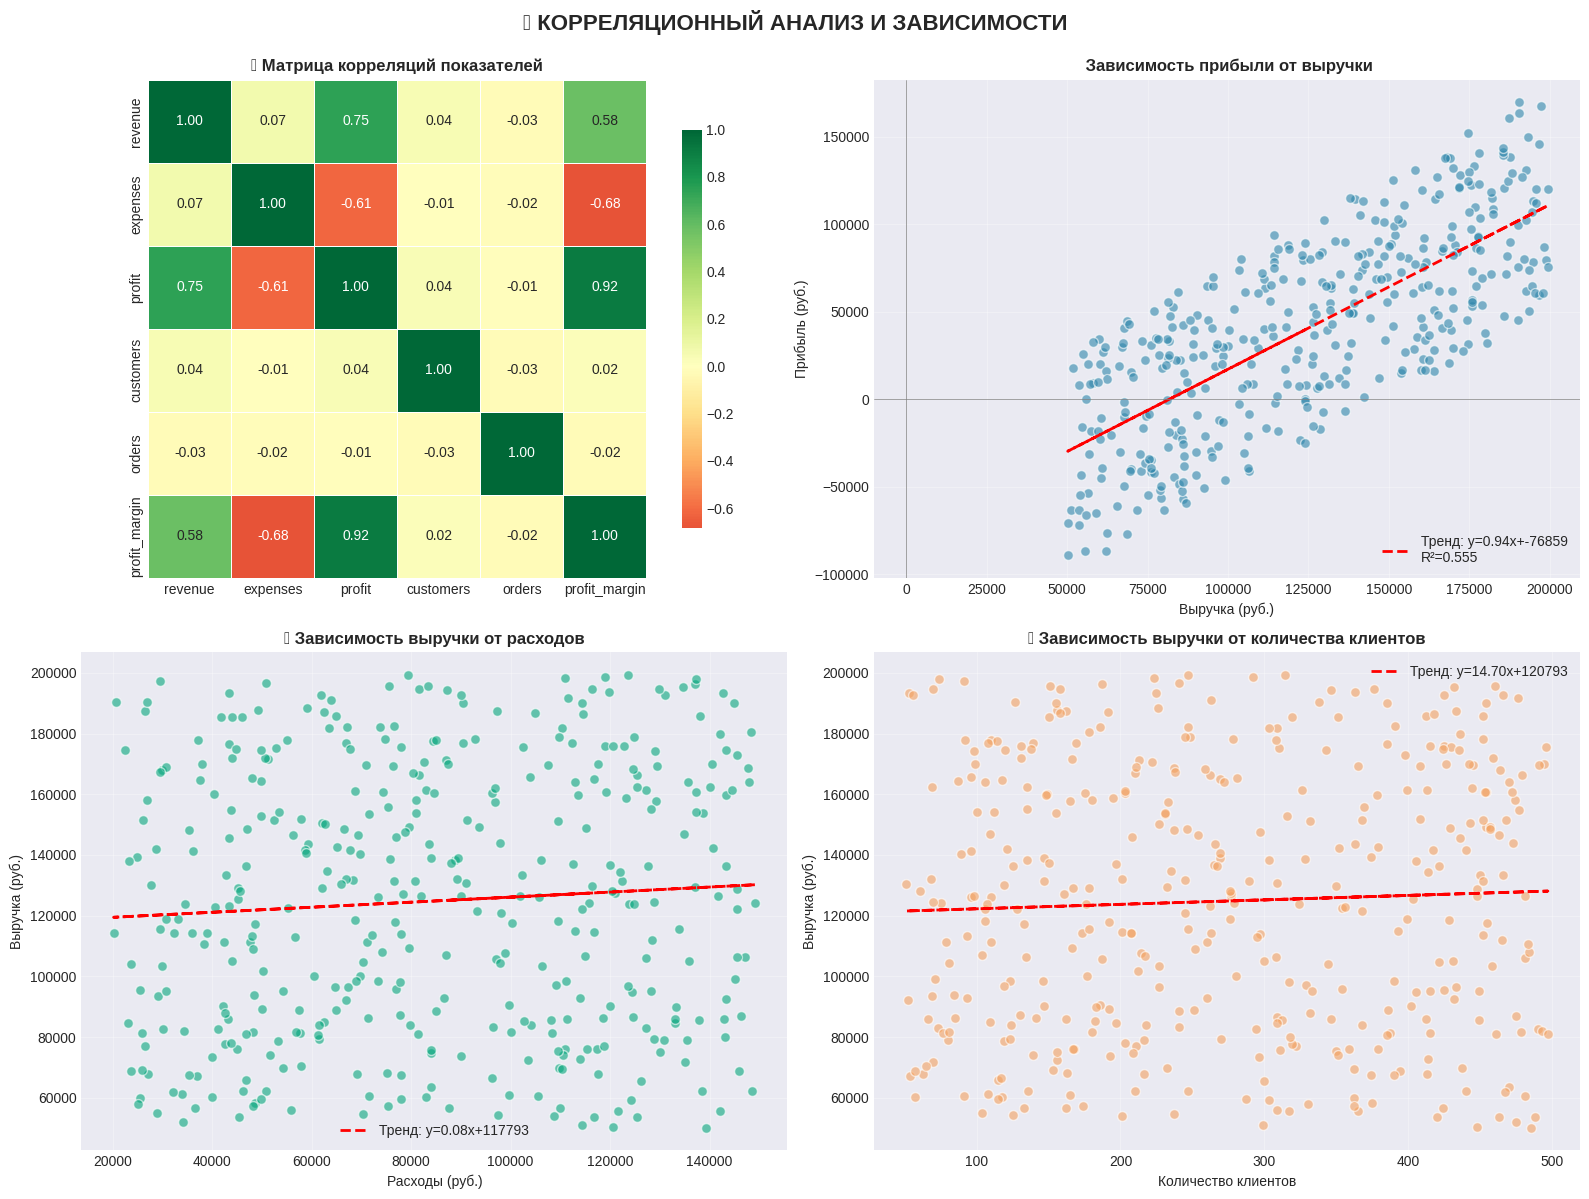

In [9]:
# =============================================================================
# 5. ВИЗУАЛИЗАЦИЯ 3: КОРРЕЛЯЦИОННЫЙ АНАЛИЗ
# =============================================================================

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('🔗 КОРРЕЛЯЦИОННЫЙ АНАЛИЗ И ЗАВИСИМОСТИ', fontsize=16, fontweight='bold', y=0.995)

# Матрица корреляций
corr_cols = ['revenue', 'expenses', 'profit', 'customers', 'orders', 'profit_margin']
corr_matrix = df[corr_cols].corr()

# График 1: Тепловая карта корреляций
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='RdYlGn', center=0,
            ax=axes[0, 0], square=True, linewidths=0.5, cbar_kws={"shrink": .8})
axes[0, 0].set_title('📊 Матрица корреляций показателей', fontweight='bold')

# График 2: Выручка vs Прибыль (scatter с трендом)
z = np.polyfit(df['revenue'], df['profit'], 1)
p = np.poly1d(z)
axes[0, 1].scatter(df['revenue'], df['profit'], alpha=0.6, color='#2E86AB', edgecolors='white', s=50)
axes[0, 1].plot(df['revenue'], p(df['revenue']), "r--", linewidth=2,
                label=f'Тренд: y={z[0]:.2f}x+{z[1]:.0f}\nR²={np.corrcoef(df["revenue"], df["profit"])[0,1]**2:.3f}')
axes[0, 1].axhline(y=0, color='gray', linestyle='-', linewidth=0.5)
axes[0, 1].axvline(x=0, color='gray', linestyle='-', linewidth=0.5)
axes[0, 1].set_title(' Зависимость прибыли от выручки', fontweight='bold')
axes[0, 1].set_xlabel('Выручка (руб.)')
axes[0, 1].set_ylabel('Прибыль (руб.)')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# График 3: Расходы vs Выручка
z2 = np.polyfit(df['expenses'], df['revenue'], 1)
p2 = np.poly1d(z2)
axes[1, 0].scatter(df['expenses'], df['revenue'], alpha=0.6, color='#06A77D', edgecolors='white', s=50)
axes[1, 0].plot(df['expenses'], p2(df['expenses']), "r--", linewidth=2,
                label=f'Тренд: y={z2[0]:.2f}x+{z2[1]:.0f}')
axes[1, 0].set_title('💰 Зависимость выручки от расходов', fontweight='bold')
axes[1, 0].set_xlabel('Расходы (руб.)')
axes[1, 0].set_ylabel('Выручка (руб.)')
axes[1, 0].legend()
axes[1, 0].grid(True, alpha=0.3)

# График 4: Клиенты vs Выручка
z3 = np.polyfit(df['customers'], df['revenue'], 1)
p3 = np.poly1d(z3)
axes[1, 1].scatter(df['customers'], df['revenue'], alpha=0.6, color='#F4A261', edgecolors='white', s=50)
axes[1, 1].plot(df['customers'], p3(df['customers']), "r--", linewidth=2,
                label=f'Тренд: y={z3[0]:.2f}x+{z3[1]:.0f}')
axes[1, 1].set_title('👥 Зависимость выручки от количества клиентов', fontweight='bold')
axes[1, 1].set_xlabel('Количество клиентов')
axes[1, 1].set_ylabel('Выручка (руб.)')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('analytics_correlation.png', dpi=300, bbox_inches='tight')
plt.show()

# Корреляционный анализ и зависимости

**График первый — Матрица корреляций показателей**
- Тепловая карта взаимосвязей между ключевыми метриками
- Наивысшая положительная корреляция: прибыль и маржинальность (0.92)
- Сильная связь: выручка и прибыль (0.75)
- Отрицательная корреляция: расходы и маржинальность (−0.68), расходы и прибыль (−0.61)
- Слабые связи: количество клиентов и заказов с остальными показателями (около 0.00–0.04)

**График второй — Зависимость прибыли от выручки**
- Scatter-plot с линией тренда
- Уравнение тренда: y = 0.94x − 76859
- Коэффициент детерминации: R² = 0.555
- Вывод: с ростом выручки прибыль увеличивается, связь умеренно сильная

**График третий — Зависимость выручки от расходов**
- Точки распределены широко, связь слабая
- Уравнение тренда: y = 0.08x + 117793
- Вывод: рост расходов не гарантирует пропорциональный рост выручки

**График четвёртый — Зависимость выручки от количества клиентов**
- Уравнение тренда: y = 14.70x + 120793
- Вывод: связь между числом клиентов и выручкой слабая, данные сильно разбросаны

In [10]:
# =============================================================================
# 6. АНАЛИЗ ЭФФЕКТИВНОСТИ И KPI
# =============================================================================

print("="*70)
print("📊 АНАЛИЗ КЛЮЧЕВЫХ ПОКАЗАТЕЛЕЙ ЭФФЕКТИВНОСТИ (KPI)")
print("="*70)

# Расчет KPI
total_days = len(df)
profitable_days = (df['profit'] > 0).sum()
high_margin_days = (df['profit_margin'] > 30).sum()
low_margin_days = (df['profit_margin'] < 10).sum()

avg_daily_revenue = df['revenue'].mean()
avg_daily_profit = df['profit'].mean()
best_day_revenue = df.loc[df['revenue'].idxmax()]
worst_day_revenue = df.loc[df['revenue'].idxmin()]
best_day_profit = df.loc[df['profit'].idxmax()]
worst_day_profit = df.loc[df['profit'].idxmin()]

print(f"""
📈 ОБЩИЕ KPI:
   • Процент прибыльных дней:      {profitable_days/total_days*100:.1f}%
   • Процент дней с высокой        {high_margin_days/total_days*100:.1f}%
     маржинальностью (>30%):
   • Процент дней с низкой         {low_margin_days/total_days*100:.1f}%
     маржинальностью (<10%):

💰 СРЕДНИЕ ДНЕВНЫЕ ПОКАЗАТЕЛИ:
   • Средняя дневная выручка:      {avg_daily_revenue:,.0f} руб.
   • Средняя дневная прибыль:      {avg_daily_profit:,.0f} руб.
   • Средняя дневная маржа:        {df['profit_margin'].mean():.2f}%

🏆 ЛУЧШИЕ ДНИ:
   • По выручке: {best_day_revenue['date'].date()}
     - Выручка: {best_day_revenue['revenue']:,.0f} руб.
     - Прибыль: {best_day_revenue['profit']:,.0f} руб.
     - Маржа: {best_day_revenue['profit_margin']:.2f}%

   • По прибыли: {best_day_profit['date'].date()}
     - Прибыль: {best_day_profit['profit']:,.0f} руб.
     - Выручка: {best_day_profit['revenue']:,.0f} руб.
     - Маржа: {best_day_profit['profit_margin']:.2f}%

⚠️ ХУДШИЕ ДНИ:
   • По выручке: {worst_day_revenue['date'].date()}
     - Выручка: {worst_day_revenue['revenue']:,.0f} руб.
     - Прибыль: {worst_day_revenue['profit']:,.0f} руб.

   • По прибыли: {worst_day_profit['date'].date()}
     - Прибыль: {worst_day_profit['profit']:,.0f} руб.
     - Выручка: {worst_day_profit['revenue']:,.0f} руб.
     - Маржа: {worst_day_profit['profit_margin']:.2f}%
""")

📊 АНАЛИЗ КЛЮЧЕВЫХ ПОКАЗАТЕЛЕЙ ЭФФЕКТИВНОСТИ (KPI)

📈 ОБЩИЕ KPI:
   • Процент прибыльных дней:      76.8%
   • Процент дней с высокой        56.0%
     маржинальностью (>30%):
   • Процент дней с низкой         28.2%
     маржинальностью (<10%):

💰 СРЕДНИЕ ДНЕВНЫЕ ПОКАЗАТЕЛИ:
   • Средняя дневная выручка:      124,795 руб.
   • Средняя дневная прибыль:      40,552 руб.
   • Средняя дневная маржа:        22.87%

🏆 ЛУЧШИЕ ДНИ:
   • По выручке: 2023-03-12
     - Выручка: 199,381 руб.
     - Прибыль: 120,028 руб.
     - Маржа: 60.20%

   • По прибыли: 2023-03-20
     - Прибыль: 169,601 руб.
     - Выручка: 190,272 руб.
     - Маржа: 89.14%

⚠️ ХУДШИЕ ДНИ:
   • По выручке: 2023-10-31
     - Выручка: 50,207 руб.
     - Прибыль: -89,039 руб.

   • По прибыли: 2023-10-31
     - Прибыль: -89,039 руб.
     - Выручка: 50,207 руб.
     - Маржа: -177.34%



⚠️ АНАЛИЗ УБЫТОЧНЫХ ДНЕЙ И РИСКОВ

📊 ОБЩИЕ ДАННЫЕ ПО УБЫТКАМ:
   • Количество убыточных дней:    93 (23.2%)
   • Общая сумма убытков:          -3,216,523 руб.
   • Средний убыток в день:        -34,586 руб.
   • Максимальный убыток за день:  -89,039 руб.
   • Доля убытков от прибыли:      19.8%

🔝 ТОП-10 НАИБОЛЕЕ УБЫТОЧНЫХ ДНЕЙ:

   2023-10-31: Прибыль=-89,039 руб., Выручка=50,207 руб., Расходы=139,246 руб., Маржа=-177.34%
   2023-04-06: Прибыль=-86,448 руб., Выручка=62,115 руб., Расходы=148,563 руб., Маржа=-139.17%
   2023-05-11: Прибыль=-86,435 руб., Выручка=55,704 руб., Расходы=142,139 руб., Маржа=-155.17%
   2023-07-25: Прибыль=-77,130 руб., Выручка=68,743 руб., Расходы=145,873 руб., Маржа=-112.20%
   2023-07-19: Прибыль=-76,238 руб., Выручка=62,289 руб., Расходы=138,527 руб., Маржа=-122.39%
   2023-05-29: Прибыль=-71,661 руб., Выручка=53,726 руб., Расходы=125,387 руб., Маржа=-133.38%
   2023-03-17: Прибыль=-70,408 руб., Выручка=50,281 руб., Расходы=120,689 руб., Маржа=-140.03%
   

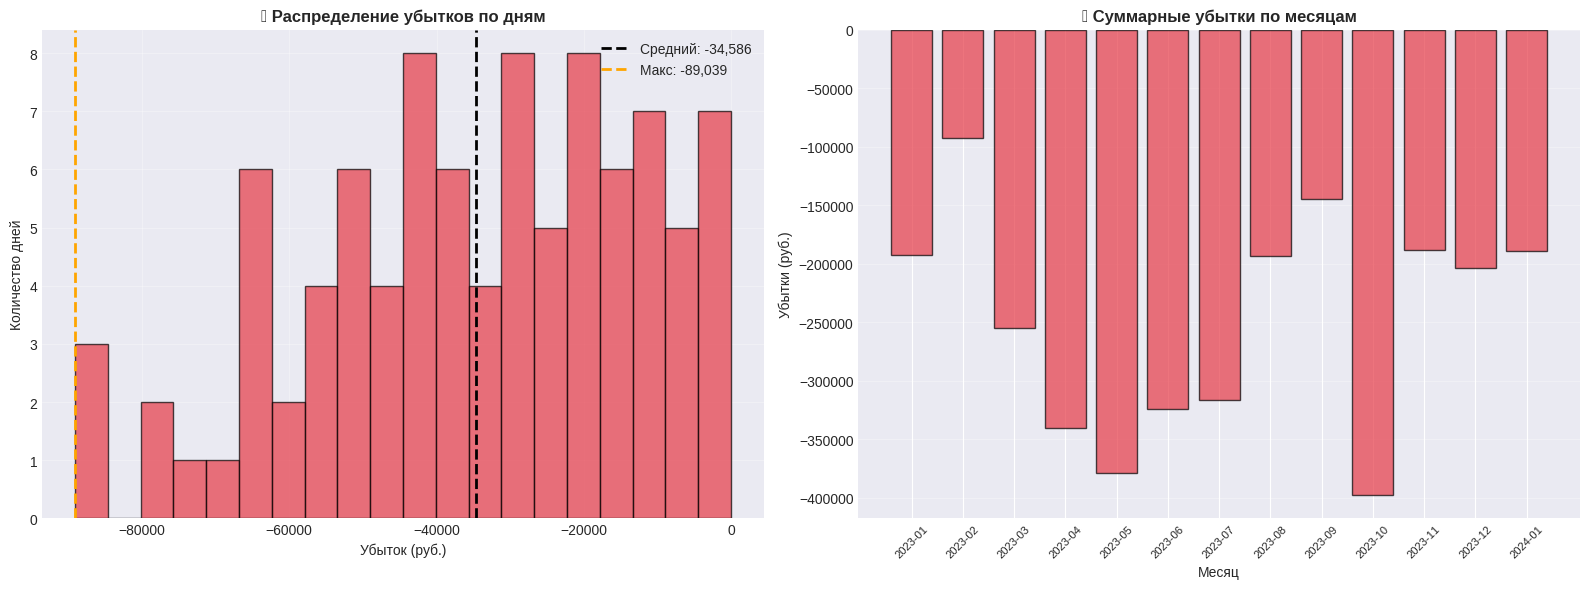

In [11]:
# =============================================================================
# 7. АНАЛИЗ РИСКОВ И УБЫТОЧНЫХ ПЕРИОДОВ
# =============================================================================

print("="*70)
print("⚠️ АНАЛИЗ УБЫТОЧНЫХ ДНЕЙ И РИСКОВ")
print("="*70)

loss_days_df = df[df['profit'] < 0].copy()
loss_days_df = loss_days_df.sort_values('profit')

total_loss = loss_days_df['profit'].sum()
avg_loss = loss_days_df['profit'].mean()
max_loss = loss_days_df['profit'].min()

print(f"""
📊 ОБЩИЕ ДАННЫЕ ПО УБЫТКАМ:
   • Количество убыточных дней:    {len(loss_days_df)} ({len(loss_days_df)/total_days*100:.1f}%)
   • Общая сумма убытков:          {total_loss:,.0f} руб.
   • Средний убыток в день:        {avg_loss:,.0f} руб.
   • Максимальный убыток за день:  {max_loss:,.0f} руб.
   • Доля убытков от прибыли:      {abs(total_loss)/total_profit*100:.1f}%

🔝 ТОП-10 НАИБОЛЕЕ УБЫТОЧНЫХ ДНЕЙ:
""")

for idx, row in loss_days_df.head(10).iterrows():
    print(f"   {row['date'].date()}: Прибыль={row['profit']:,.0f} руб., "
          f"Выручка={row['revenue']:,.0f} руб., "
          f"Расходы={row['expenses']:,.0f} руб., "
          f"Маржа={row['profit_margin']:.2f}%")

# Анализ причин убытков
print(f"""
🔍 АНАЛИЗ ПРИЧИН УБЫТКОВ:
   • Средняя выручка в убыточные дни:     {loss_days_df['revenue'].mean():,.0f} руб.
   • Средняя выручка в прибыльные дни:    {df[df['profit']>0]['revenue'].mean():,.0f} руб.
   • Разница:                             {(df[df['profit']>0]['revenue'].mean() - loss_days_df['revenue'].mean()):,.0f} руб.

   • Средние расходы в убыточные дни:     {loss_days_df['expenses'].mean():,.0f} руб.
   • Средние расходы в прибыльные дни:    {df[df['profit']>0]['expenses'].mean():,.0f} руб.
   • Разница:                             {(loss_days_df['expenses'].mean() - df[df['profit']>0]['expenses'].mean()):,.0f} руб.

   • Среднее кол-во клиентов (убыточные): {loss_days_df['customers'].mean():.0f}
   • Среднее кол-во клиентов (прибыльные):{df[df['profit']>0]['customers'].mean():.0f}
""")

# Визуализация убыточных дней
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# График 1: Распределение убытков
axes[0].hist(loss_days_df['profit'], bins=20, color='#E63946', edgecolor='black', alpha=0.7)
axes[0].axvline(avg_loss, color='black', linestyle='--', linewidth=2, label=f'Средний: {avg_loss:,.0f}')
axes[0].axvline(max_loss, color='orange', linestyle='--', linewidth=2, label=f'Макс: {max_loss:,.0f}')
axes[0].set_title('📊 Распределение убытков по дням', fontweight='bold')
axes[0].set_xlabel('Убыток (руб.)')
axes[0].set_ylabel('Количество дней')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# График 2: Убытки по месяцам
loss_by_month = loss_days_df.groupby('month')['profit'].sum().reset_index()
axes[1].bar(range(len(loss_by_month)), loss_by_month['profit'],
            color='#E63946', edgecolor='black', alpha=0.7)
axes[1].set_title('📅 Суммарные убытки по месяцам', fontweight='bold')
axes[1].set_xlabel('Месяц')
axes[1].set_ylabel('Убытки (руб.)')
axes[1].set_xticks(range(len(loss_by_month)))
axes[1].set_xticklabels(loss_by_month['month'].astype(str), rotation=45, fontsize=8)
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('analytics_losses.png', dpi=300, bbox_inches='tight')
plt.show()

# Анализ убытков

**График первый — Распределение убытков по дням**
- Ось X: значения убытков в рублях (от −80 000 до 0)
- Ось Y: количество дней с соответствующим уровнем потерь
- Средний убыток: −34 586 рублей
- Максимальный убыток: −89 039 рублей
- Основная масса дней: диапазон от −40 000 до −20 000 рублей

**График второй — Суммарные убытки по месяцам**
- Период: январь 2023 — январь 2024
- Ось X: месяцы
- Ось Y: сумма убытков в рублях
- Наиболее убыточный месяц: октябрь 2023 (около −400 000 рублей)
- Значительные потери: апрель и май 2023 года
- Наименьшие убытки: февраль и сентябрь 2023 года

In [12]:
# =============================================================================
# 6. ЭКСПОРТ РЕЗУЛЬТАТОВ
# =============================================================================

# Сохранение агрегированных данных
summary_report = pd.DataFrame({
    'Показатель': ['Общая выручка', 'Общие расходы', 'Общая прибыль',
                   'Средняя выручка/день', 'Средняя прибыль/день',
                   'Средняя рентабельность, %', 'Всего клиентов', 'Всего заказов'],
    'Значение': [
        df['revenue'].sum(),
        df['expenses'].sum(),
        df['profit'].sum(),
        df['revenue'].mean(),
        df['profit'].mean(),
        df['profit_margin'].mean(),
        df['customers'].sum(),
        df['orders'].sum()
    ]
})

summary_report.to_csv('analytics_summary.csv', index=False, encoding='utf-8-sig')
print("✅ Отчёт экспортирован в файл 'analytics_summary.csv'")

# Экспорт ежемесячной динамики
monthly_df.to_csv('monthly_analytics.csv', index=False, encoding='utf-8-sig')
print("✅ Ежемесячная аналитика экспортирована в 'monthly_analytics.csv'")

print("\n🎉 Анализ завершён успешно!")

✅ Отчёт экспортирован в файл 'analytics_summary.csv'
✅ Ежемесячная аналитика экспортирована в 'monthly_analytics.csv'

🎉 Анализ завершён успешно!
